In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [4]:
train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

c:\Users\ZORO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

In [7]:
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [8]:
images, labels = next((iter(train_loader)))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [9]:
classes = train_data.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
print(labels[0])
print(classes[labels[0]])

tensor(5)
dog


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


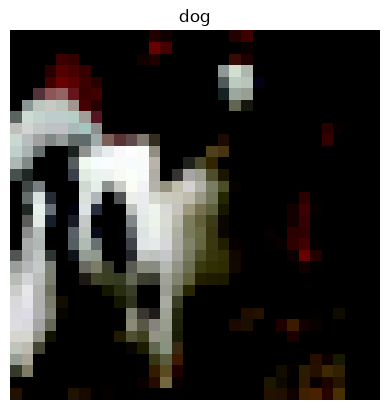

In [11]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1, 2, 0))
plt.title(classes[labels[0]])
plt.axis("off")
plt.show()

In [12]:
images[0].permute(1, 2, 0).shape

torch.Size([32, 32, 3])

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward (self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x;

In [14]:
model = CNN().to(device)

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [16]:
best_acc = 0.0

for epoch in range(20):

    # ---- TRAIN ----
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # --- TEST ----

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total

    # ---- SAVE BEST MODEL ----
    if test_acc > best_acc:
        best_acc = test_acc

        torch.save(
            model.state_dict(),
            "best_cifar10.pth"
        )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}: "
        f"Loss {running_loss / len(train_loader):.4f} | "
        f"Train {train_acc:.2f}% | "
        f"Test {test_acc:.2f}% | "
        f"LR {optimizer.param_groups[0]['lr']:.6f}"
    )

print(f"\nBest test accuracy: {best_acc:.2f}%")

Epoch 1: Loss 1.5661 | Train 42.38% | Test 56.51% | LR 0.000994
Epoch 2: Loss 1.2438 | Train 55.26% | Test 61.93% | LR 0.000976
Epoch 3: Loss 1.1128 | Train 60.49% | Test 65.77% | LR 0.000946
Epoch 4: Loss 1.0359 | Train 63.69% | Test 67.02% | LR 0.000905
Epoch 5: Loss 0.9679 | Train 65.99% | Test 70.12% | LR 0.000854
Epoch 6: Loss 0.9152 | Train 68.11% | Test 70.04% | LR 0.000794
Epoch 7: Loss 0.8729 | Train 69.71% | Test 74.24% | LR 0.000727
Epoch 8: Loss 0.8348 | Train 71.03% | Test 73.09% | LR 0.000655
Epoch 9: Loss 0.8041 | Train 72.43% | Test 76.07% | LR 0.000578
Epoch 10: Loss 0.7644 | Train 73.74% | Test 75.98% | LR 0.000500
Epoch 11: Loss 0.7373 | Train 74.64% | Test 75.60% | LR 0.000422
Epoch 12: Loss 0.7186 | Train 75.38% | Test 77.50% | LR 0.000345
Epoch 13: Loss 0.6886 | Train 76.36% | Test 77.82% | LR 0.000273
Epoch 14: Loss 0.6657 | Train 77.07% | Test 79.25% | LR 0.000206
Epoch 15: Loss 0.6490 | Train 77.68% | Test 78.93% | LR 0.000146
Epoch 16: Loss 0.6356 | Train 78.2

In [17]:
model.load_state_dict(
    torch.load("best_cifar10.pth")
)

model.eval()

print(f"Best accuracy achieved: {best_acc:.2f}%")

Best accuracy achieved: 80.41%


In [61]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 79.60%


In [62]:
image, label = test_data[0]

image = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    x = model.conv1(image)
    x = torch.relu(model.bn1(x))

print(x.shape)

torch.Size([1, 32, 32, 32])


torch.Size([32, 32, 32])


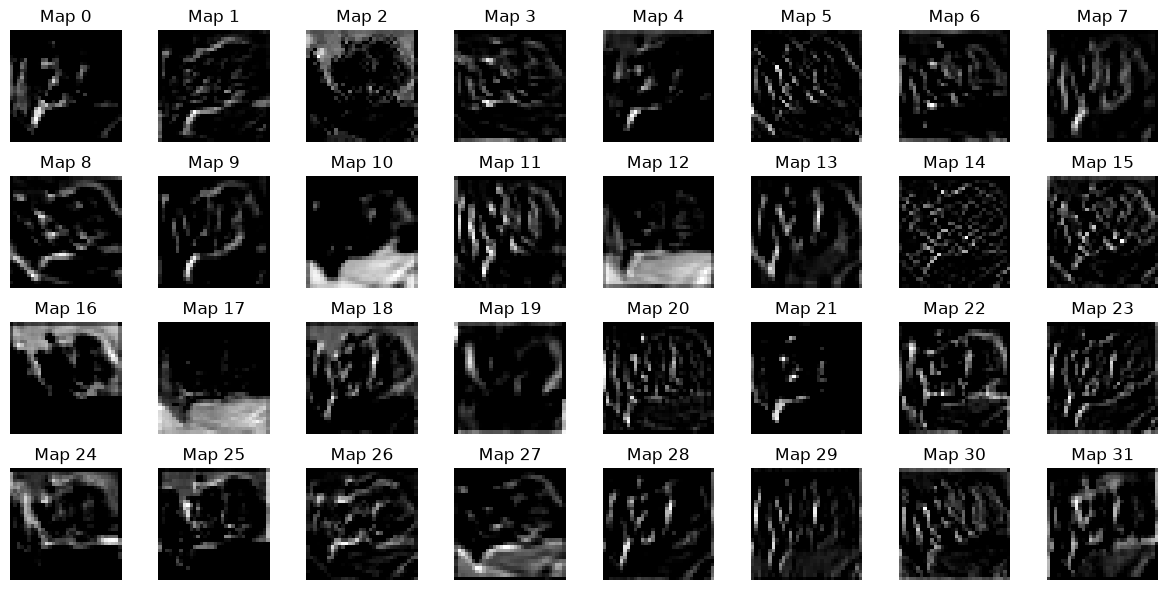

In [63]:
feature_maps = x.squeeze(0).cpu()

print(feature_maps.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"Map {i}")

plt.tight_layout()
plt.show()

In [64]:
with torch.no_grad():
    x = model.conv1(image)
    x = torch.relu(model.bn1(x))

    x = model.conv2(x)
    x = torch.relu(model.bn2(x))

feature_maps = x.squeeze(0).cpu()

print(feature_maps.shape)

torch.Size([64, 32, 32])


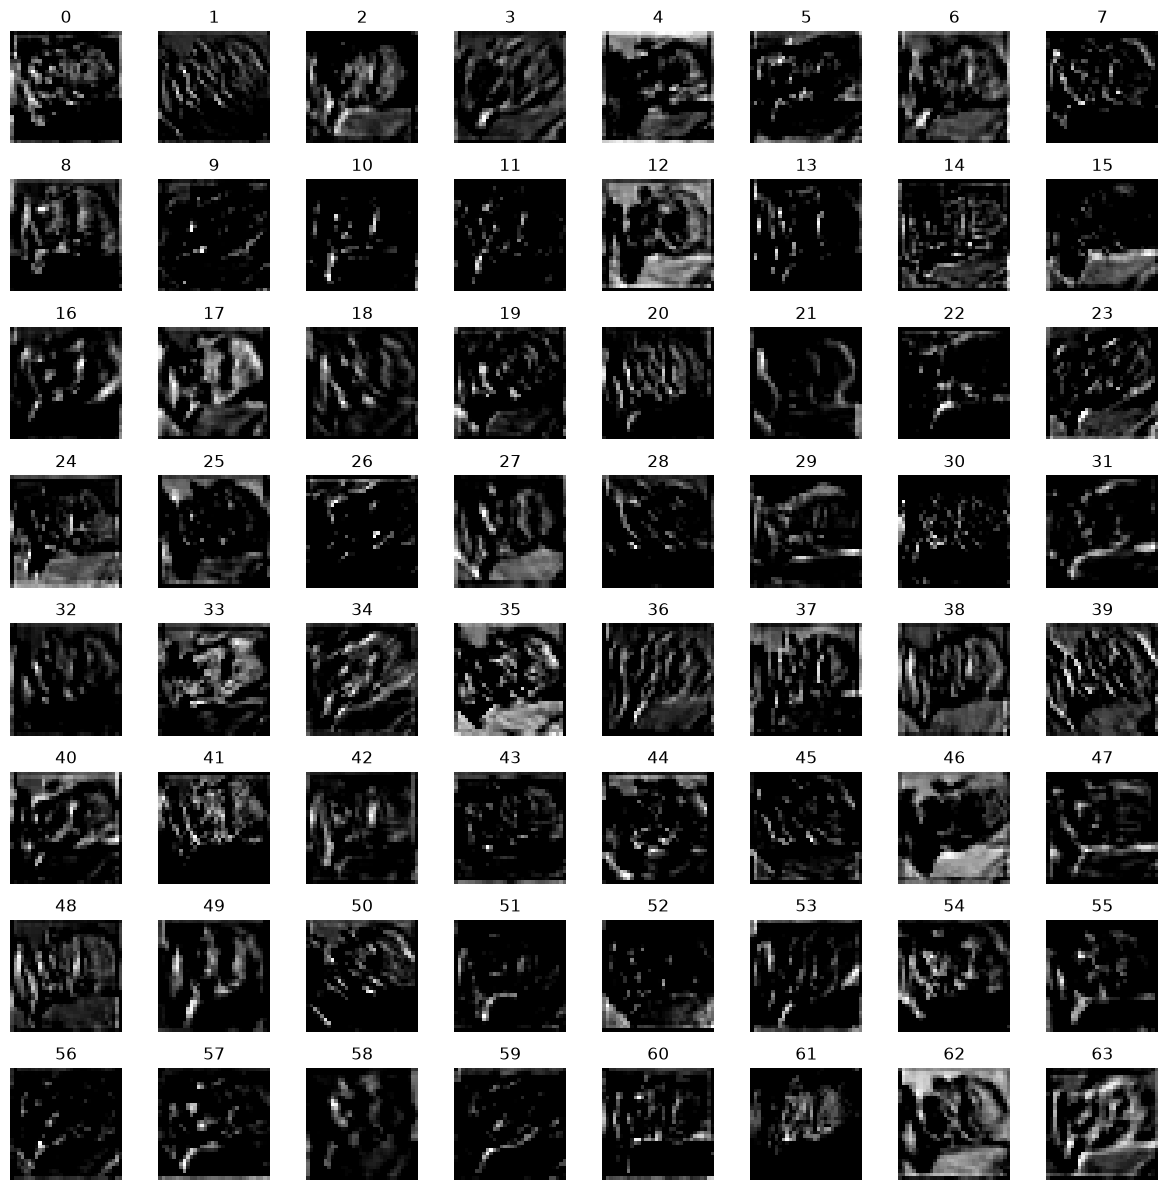

In [65]:
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"{i}")

plt.tight_layout()
plt.show()